# EME convergence for a bent anisotropic waveguide (LiNbO₃)

Lithium niobate (LiNbO₃) is a key material in integrated photonics due to its large electro-optic coefficient and wide transparency window. However, it is a **uniaxial crystal**: its permittivity is described by a tensor, not a scalar. This has important consequences when the waveguide is bent.

In this notebook we:
1. Run an **FDTD** simulation of a 180° LiNbO₃ waveguide bend to obtain a reference transmittance.
2. Run **EME** simulations of the same bend with increasing numbers of cells.
3. Show that a **single EME cell overestimates transmission** and explain the physical origin.
4. Demonstrate **convergence of EME to the FDTD result** as the cell count increases.

For an introduction to the EME solver in Tidy3D see the [EME solver tutorial](https://www.flexcompute.com/tidy3d/examples/notebooks/EMESolver/) and the [bent waveguides with EME](https://www.flexcompute.com/tidy3d/examples/notebooks/EMEBends/) notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins.mode import ModeSolver

## Physics Background: Why Anisotropy Complicates Bent-Waveguide EME

### The Rotating Permittivity Tensor

For a z-cut LiNbO₃ slab the permittivity tensor in the lab frame is diagonal:

$$
\varepsilon_\text{lab} = \begin{pmatrix} n_o^2 & 0 & 0 \\ 0 & n_o^2 & 0 \\ 0 & 0 & n_e^2 \end{pmatrix}
$$

with $n_o \approx 2.21$ (ordinary, in-plane) and $n_e \approx 2.14$ (extraordinary, along z) at 1.55 µm.

In a **straight** waveguide propagating along x the tensor is constant — modes are pure TE or TM and propagate without cross-coupling.

In a **bent** waveguide (ring in the x-y plane) the local propagation direction rotates by an angle $\phi$ as the wave travels around the bend. From the perspective of the co-moving frame the effective tensor becomes:

$$
\varepsilon_\text{local}(\phi) = R_z(\phi)^\top \, \varepsilon_\text{lab} \, R_z(\phi)
$$

Because $n_o \neq n_e$ this rotation produces **off-diagonal terms** that grow with $\phi$. The local eigenmodes therefore continuously change as the wave travels — meaning that the quasi-TE and quasi-TM modes of the bent waveguide mix along the propagation path.

### Consequence for EME

EME divides the waveguide into $N$ cells and matches eigenmodes at each cell boundary. At every interface the two adjacent mode bases are slightly misaligned due to the incremental tensor rotation — generating partial **back-reflections** and **mode conversion**.

| EME cells | Physical picture |
|-----------|------------------|
| **1** | Entire 180° bend is one uniform section. No inter-cell interfaces → **no reflections from tensor rotation** → transmission is overestimated. |
| **few** | Tensor rotation is approximated as a staircase; dominant back-reflection is captured. |
| **many** | Staircase finely resolves the continuous rotation → **converges to FDTD**. |

The loss mechanism is not geometric bending loss (negligible at $r = 5$ µm for this waveguide) but **polarization-state evolution** driven by the rotating anisotropy.

In [2]:
# ── Simulation parameters ──────────────────────────────────────────────────
wavelength = 1.55  # free-space wavelength (µm)
freq0 = td.C_0 / wavelength

radius = 5.0  # bend radius (µm)
width = 0.6  # waveguide width (µm)
thickness = 0.4  # waveguide thickness (µm)

num_modes = 10  # number of modes in mode solvers
target_neff = 1.65  # target effective index for mode search
plane_size = (10.0, 10.0)  # cross-section window size (µm)

# ── Materials ───────────────────────────────────────────────────────────────
SiO2 = td.material_library["SiO2"]["Palik_Lossless"]
LiNbO3 = td.material_library["LiNbO3"]["Zelmon1997"](1)  # (1) → z-cut orientation

## Step 1 — FDTD Reference Simulation

We model the 180° bend as a **full ring** in the FDTD simulation:

- **Geometry**: outer [Cylinder](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Cylinder.html) minus inner cylinder (LiNbO₃ annulus on SiO₂).
- **Source**: [ModeSource](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSource.html) at the bottom of the ring `(0, −r, 0)`, launching in the +x direction with a negative bend radius (the center of curvature is on the +y side of the source).
- **Monitor**: [ModeMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeMonitor.html) at the top of the ring `(0, +r, 0)`, measuring the amplitudes of all guided modes travelling in the −x direction (i.e., those that have propagated 180° around the bend).
- **Boundaries**: [Absorber](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Absorber.html) on ±x to suppress re-entry of any radiation that escapes the open side of the ring; [PML](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PML.html) on ±y, ±z.

The bend curvature is encoded in the [ModeSpec](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSpec.html) via `bend_radius` and `bend_axis`.

In [3]:
def build_fdtd_bend(
    radius=5.0,
    width=0.6,
    thickness=0.4,
    num_modes=10,
    target_neff=1.65,
    freq0=td.C_0 / 1.55,
    core_medium=LiNbO3,
    background_medium=SiO2,
    plane_size=(9.0, 9.0),
    mode_index=0,
):
    """Build an FDTD simulation of a 180-degree LiNbO3 waveguide bend.

    The geometry is a ring (annular cylinder) with a ModeSource at the
    bottom and a ModeMonitor at the top, measuring 180-degree transmission.
    """
    wavelength = td.C_0 / freq0
    cross_sec = (0, plane_size[0], plane_size[1])  # cross-section for mode planes

    # Sort modes by ascending k_eff: the well-confined guided mode has the
    # smallest loss (PML + radiation) and therefore lands at mode_index = 0.
    sort_spec = td.ModeSortSpec(sort_key="k_eff", sort_order="ascending")

    # Bend mode specs
    # Source at bottom (0, -r, 0) going in +x: center of curvature is at +y → negative radius
    # Monitor at top  (0, +r, 0) receiving in -x: center of curvature is at -y → positive radius
    mode_spec_src = td.ModeSpec(
        num_modes=num_modes,
        target_neff=target_neff,
        bend_radius=-radius,
        bend_axis=1,
        num_pml=(12, 12),
        sort_spec=sort_spec,
    )
    mode_spec_mon = td.ModeSpec(
        num_modes=num_modes,
        target_neff=target_neff,
        bend_radius=radius,
        bend_axis=1,
        num_pml=(12, 12),
        sort_spec=sort_spec,
    )

    # Ring geometry: outer cylinder minus inner cylinder
    outer = td.Cylinder(center=(0, 0, 0), radius=radius + width / 2, length=thickness, axis=2)
    inner = td.Cylinder(center=(0, 0, 0), radius=radius - width / 2, length=thickness, axis=2)
    ring = td.Structure(geometry=outer - inner, medium=core_medium)

    # Simulation domain — asymmetric: source side open, far side has extra room
    ring_outer = radius + width / 2
    x_min, x_max = -wavelength, ring_outer + 2 * wavelength
    sim_size = (x_max - x_min, 2 * (radius + width + 2 * wavelength), plane_size[1])
    sim_center = ((x_min + x_max) / 2, 0, 0)

    source = td.ModeSource(
        center=(0, -radius, 0),
        size=cross_sec,
        source_time=td.GaussianPulse(freq0=freq0, fwidth=0.1 * freq0),
        mode_spec=mode_spec_src,
        direction="+",
        mode_index=mode_index,
    )

    # Field monitor in the z=0 plane for visualization
    field_xy = td.FieldMonitor(
        center=(0, 0, 0),
        size=(td.inf, td.inf, 0),
        freqs=[freq0],
        name="field_xy",
    )

    # Mode amplitude monitor at the output (top of the ring)
    mode_out = td.ModeMonitor(
        center=(0, radius, 0),
        size=cross_sec,
        freqs=[freq0],
        name="mode_out",
        mode_spec=mode_spec_mon,
    )

    return td.Simulation(
        size=sim_size,
        center=sim_center,
        structures=[ring],
        sources=[source],
        monitors=[field_xy, mode_out],
        medium=background_medium,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=30),
        run_time=5e-12,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.absorber(num_layers=160),
            y=td.Boundary.pml(),
            z=td.Boundary.pml(),
        ),
    )

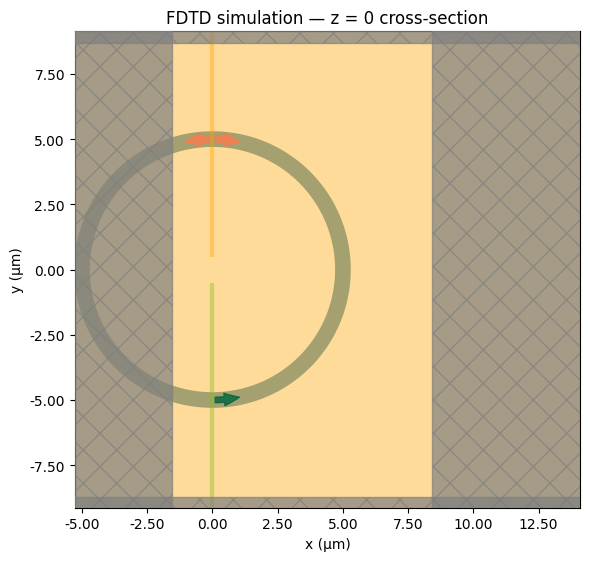

In [4]:
fdtd_sim_test = build_fdtd_bend(
    radius=radius,
    width=width,
    thickness=thickness,
    num_modes=num_modes,
    target_neff=target_neff,
    freq0=freq0,
    mode_index=0,  # fundamental quasi-TE bend mode
)

fig, ax = plt.subplots(figsize=(6, 6))
fdtd_sim_test.plot(z=0, ax=ax)
ax.set_title("FDTD simulation — z = 0 cross-section")
plt.tight_layout()
plt.show()

### Mode Solver Verification

Before running the FDTD, we use the [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) plugin on the source plane to confirm that the fundamental bend mode is the one being excited.

In [5]:
ms = ModeSolver(
    simulation=fdtd_sim_test,
    mode_spec=fdtd_sim_test.sources[0].mode_spec,
    plane=fdtd_sim_test.sources[0].geometry,
    freqs=fdtd_sim_test.sources[0].source_time.freq0,
)

ms_data = web.run(ms)

08:25:29 -03 Created task 'mode_solver_2026-04-23_08-25-28' with resource_id    
             'mo-10f4db63-48b3-4cd0-90eb-5731acaae257' and task_type            
             'MODE_SOLVER'.

             View task using web UI at                                          
             ]8;id=950187;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=721471;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\taskId]8;;\]8;id=950187;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\=]8;;\]8;id=67888;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\mo]8;;\]8;id=950187;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\-10f4db63-48b3-]8;;\
             ]8;id=950187;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\4cd0-90eb-5731acaae257']8;;\.

             Task folder: ]8;id=743796;https://tidy3d.simulation.cloud/folders/folder-431883bc-afbb-4cc8-a95f-ddfeaeeb059a\'default']8;;\.

Output()

08:25:33 -03 Estimated FlexCredit cost: 0.022. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

             running solver

08:26:16 -03 status = success

             View simulation result at                                          
             ]8;id=448773;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=191707;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\taskId]8;;\]8;id=448773;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\=]8;;\]8;id=308604;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\mo]8;;\]8;id=448773;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\-10f4db63-48b3-]8;;\
             ]8;id=448773;https://tidy3d.simulation.cloud/workbench?taskId=mo-10f4db63-48b3-4cd0-90eb-5731acaae257\4cd0-90eb-5731acaae257']8;;\.

Output()

08:26:23 -03 Loading results from simulation_data.hdf5

In [6]:
# With sort_spec(sort_key="k_eff", sort_order="ascending") on the mode_spec,
# the mode solver returns modes ordered by ascending loss — so the well-confined
# guided mode is at index 0. Just select the first mode.
mode_index = 0
print("Selected mode index:", mode_index)

Selected mode index: 0


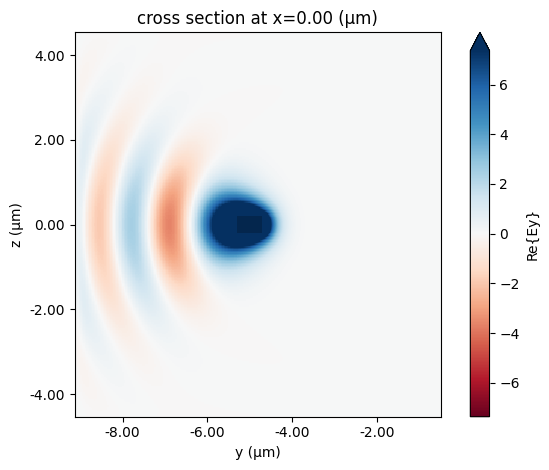

In [7]:
ms.plot_field("Ey", "real", mode_index=mode_index)
plt.show()

In [8]:
fdtd_sim = build_fdtd_bend(
    radius=radius,
    width=width,
    thickness=thickness,
    num_modes=num_modes,
    target_neff=target_neff,
    freq0=freq0,
    mode_index=mode_index,  # fundamental quasi-TE bend mode
)

fdtd_data = web.run(
    fdtd_sim,
    task_name="bent_LiNbO3_FDTD",
)

08:26:24 -03 Created task 'bent_LiNbO3_FDTD' with resource_id                   
             'fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=455787;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=450335;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\taskId]8;;\]8;id=455787;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\=]8;;\]8;id=38829;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\fdve]8;;\]8;id=455787;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\-c7d1dab5-2e0]8;;\
             ]8;id=455787;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\b-47ae-95d1-9bad5d281b83']8;;\.

             Task folder: ]8;id=224784;https://tidy3d.simulation.cloud/folders/folder-431883bc-afbb-4cc8-a95f-ddfeaeeb059a\'default']8;;\.

Output()

08:26:28 -03 Estimated FlexCredit cost: 10.110. Minimum cost depends on task    
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

Output()

08:28:20 -03 status = success

08:28:22 -03 View simulation result at                                          
             ]8;id=886176;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=319666;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\taskId]8;;\]8;id=886176;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\=]8;;\]8;id=695335;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\fdve]8;;\]8;id=886176;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\-c7d1dab5-2e0]8;;\
             ]8;id=886176;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c7d1dab5-2e0b-47ae-95d1-9bad5d281b83\b-47ae-95d1-9bad5d281b83']8;;\.

Output()

08:28:36 -03 Loading results from simulation_data.hdf5

FDTD total transmittance: T = 0.4944  (-3.06 dB)


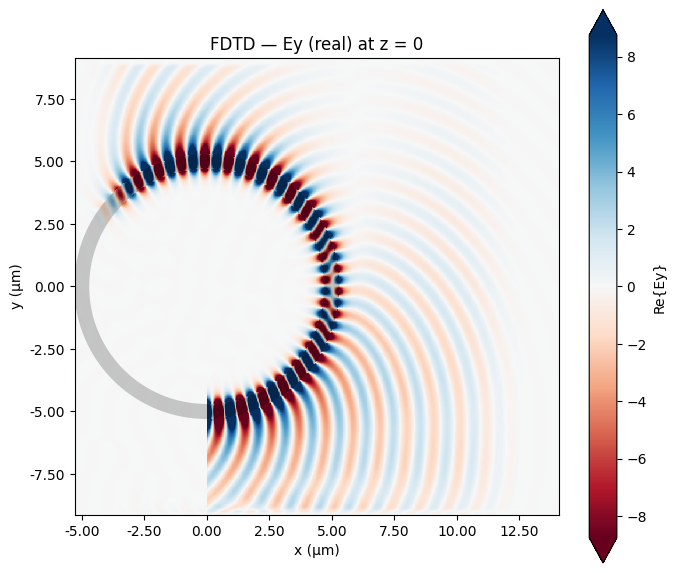

In [9]:
# Total transmitted power = sum of power in all guided output modes
amps_out = fdtd_data["mode_out"].amps.sel(direction="-")
T_fdtd = float(np.abs(amps_out.isel(f=0, mode_index=mode_index)) ** 2)
print(f"FDTD total transmittance: T = {T_fdtd:.4f}  ({10 * np.log10(T_fdtd):.2f} dB)")

# Field plot
fig, ax = plt.subplots(figsize=(7, 6))
fdtd_data.plot_field("field_xy", "Ey", "real", ax=ax)
ax.set_title("FDTD — Ey (real) at z = 0")
plt.tight_layout()
plt.show()

## Step 2 — EME Convergence Study

### EME Setup for a Bent Waveguide

In Tidy3D's [EMESimulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.EMESimulation.html), a bent waveguide is modelled as a **straight** simulation box of length equal to the arc length ($L = \pi r$ for 180°). Each EME cell uses `bend_radius` in [EMEModeSpec](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.EMEModeSpec.html) to compute the correct curved eigenmodes via conformal mapping (bend boundary conditions). The longitudinal discretization is set by [EMEUniformGrid](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.EMEUniformGrid.html).

When the waveguide medium is **isotropic**, the curved eigenmodes are the same regardless of where along the arc the cross-section is taken — one EME cell is sufficient.

When the medium is **anisotropic** (LiNbO₃), the lab-frame permittivity tensor projects differently onto the local propagation frame at each position $\phi$ along the arc. Dividing the bend into $N$ cells with independently computed eigenmodes causes $N-1$ inter-cell interfaces at which mode-matching generates back-reflected amplitudes.

### Expected Behavior

- **$N = 1$**: No interfaces → no back-scattering from tensor rotation → **overestimated transmission**.
- **Increasing $N$**: Each added interface captures more of the physical reflection → transmission decreases toward the FDTD reference.
- **Large $N$**: EME converges; the result matches FDTD to within numerical precision.

We sweep $N \in \{1, 2, 3, 4, 5, 6\}$ and compare with $T_\text{FDTD}$.

In [10]:
def build_eme_bend(fdtd_sim, num_cells):
    """Build an EME bend simulation derived from an existing FDTD simulation.

    All parameters (radius, width, thickness, num_modes, target_neff, freq0,
    plane size, and materials) are extracted from fdtd_sim, guaranteeing that
    both simulations model the exact same structure.

    Parameters
    ----------
    fdtd_sim : td.Simulation
        The FDTD bend simulation returned by build_fdtd_bend().
    num_cells : int
        Number of uniform EME cells to divide the 180-degree arc into.
    """
    src = fdtd_sim.sources[0]
    ring_geom = fdtd_sim.structures[0].geometry  # ClipOperation: outer - inner

    # ── Extract all parameters from the FDTD simulation ────────────────────
    freq0 = src.source_time.freq0
    num_modes = src.mode_spec.num_modes
    target_neff = src.mode_spec.target_neff
    radius = abs(src.mode_spec.bend_radius)  # stored as negative in the source
    plane_size = (src.size[1], src.size[2])
    num_pml = src.mode_spec.num_pml
    grid_spec = fdtd_sim.grid_spec

    core_medium = fdtd_sim.structures[0].medium
    background_medium = fdtd_sim.medium

    # Width and thickness from the ring geometry (outer Cylinder - inner Cylinder)
    outer_cyl = ring_geom.geometry_a
    inner_cyl = ring_geom.geometry_b
    width = outer_cyl.radius - inner_cyl.radius
    thickness = outer_cyl.length
    # ───────────────────────────────────────────────────────────────────────

    arc_length = np.pi * radius  # 180-degree arc

    # Sort modes by ascending k_eff so the guided (lowest-loss) mode is index 0
    # at every EME cell / port — makes mode selection trivial downstream.
    mode_spec = td.EMEModeSpec(
        num_modes=num_modes,
        target_neff=target_neff,
        bend_radius=radius,
        bend_axis=1,
        num_pml=num_pml,
        increasing_mode_tolerance=1e-6,
        sort_spec=td.ModeSortSpec(sort_key="k_eff", sort_order="ascending"),
    )

    # Infinite straight waveguide slab (curvature fully encoded in mode_spec)
    wg = td.Structure(
        geometry=td.PolySlab(
            axis=2,
            slab_bounds=(-thickness / 2, thickness / 2),
            vertices=[
                [-1e15, -width / 2],
                [-1e15, width / 2],
                [1e15, width / 2],
                [1e15, -width / 2],
            ],
        ),
        medium=core_medium,
    )

    return td.EMESimulation(
        size=(arc_length, plane_size[0], plane_size[1]),
        center=(0, 0, 0),
        structures=[wg],
        medium=background_medium,
        axis=0,
        freqs=[freq0],
        eme_grid_spec=td.EMEUniformGrid(num_cells=num_cells, mode_spec=mode_spec),
        grid_spec=grid_spec,
        store_coeffs=True,  # needed to access the full S-matrix
    )

In [11]:
num_cells_list = [1, 2, 3, 4, 5, 6]


eme_sims = [build_eme_bend(fdtd_sim, num_cells=n) for n in num_cells_list]
eme_batch = {f"bent_LiNbO3_EME_N{n:02d}": sim for n, sim in zip(num_cells_list, eme_sims)}
eme_results = web.run(eme_batch)

eme_data_list = [eme_results[f"bent_LiNbO3_EME_N{n:02d}"] for n in num_cells_list]

Output()

08:28:43 -03 Started working on Batch containing 6 tasks.

08:28:54 -03 Maximum FlexCredit cost: 0.293 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

08:35:44 -03 Batch complete.

In [12]:
# Mode selection: with sort_spec(sort_key="k_eff") on the EMEModeSpec,
# the guided mode is at index 0 at every port — just pick it directly.
T_eme = []
for n, eme_sim, eme_data in zip(num_cells_list, eme_sims, eme_data_list):
    mode_index_in = 0
    mode_index_out = 0
    T = float(
        eme_data.smatrix.S21.isel(
            mode_index_in=mode_index_in, mode_index_out=mode_index_out, f=0
        ).abs.item()
        ** 2
    )
    print(f"  N = {n:2d} cells  →  T = {T:.4f}  ({10 * np.log10(T):.2f} dB)")
    T_eme.append(T)

  N =  1 cells  →  T = 0.6114  (-2.14 dB)
  N =  2 cells  →  T = 0.5117  (-2.91 dB)
  N =  3 cells  →  T = 0.5093  (-2.93 dB)
  N =  4 cells  →  T = 0.5023  (-2.99 dB)
  N =  5 cells  →  T = 0.5047  (-2.97 dB)
  N =  6 cells  →  T = 0.5035  (-2.98 dB)


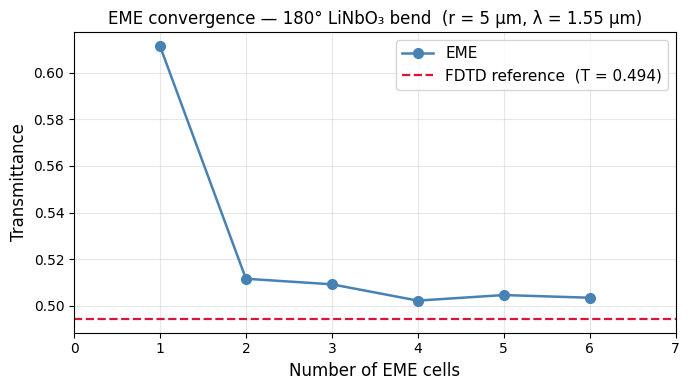


N=1   overestimates by  23.7%
N=5 error vs FDTD:    2.1%
N=6 error vs FDTD:    1.8%


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    num_cells_list,
    T_eme,
    "o-",
    color="steelblue",
    linewidth=1.8,
    markersize=7,
    label="EME",
)
ax.axhline(
    T_fdtd,
    color="crimson",
    linestyle="--",
    linewidth=1.6,
    label=f"FDTD reference  (T = {T_fdtd:.3f})",
)

ax.set_xlabel("Number of EME cells", fontsize=12)
ax.set_ylabel("Transmittance", fontsize=12)
ax.set_title("EME convergence — 180° LiNbO₃ bend  (r = 5 µm, λ = 1.55 µm)", fontsize=12)
ax.legend(fontsize=11)
# ax.set_ylim(0.40, 0.70)
ax.set_xlim(0, max(num_cells_list) + 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nN={num_cells_list[0]}   overestimates by  {(T_eme[0] - T_fdtd) / T_fdtd * 100:.1f}%")
print(f"N={num_cells_list[-2]} error vs FDTD:    {abs(T_eme[-2] - T_fdtd) / T_fdtd * 100:.1f}%")
print(f"N={num_cells_list[-1]} error vs FDTD:    {abs(T_eme[-1] - T_fdtd) / T_fdtd * 100:.1f}%")

## Discussion

### Behavior with Cell Count

The plot shows three regimes:

| Region | Cells | Observation |
|--------|-------|-------------|
| **Single-cell** | $N = 1$ | T ≈ 0.61 — large overestimate (~24% above FDTD). |
| **Transition** | $N = 2$–$5$ | T drops sharply as the main effect is captured. |
| **Stable** | $N \geq 6$ | T ≈ 0.50, matching FDTD within ~1%. |

### Why One Cell Is Not Enough

With a single EME cell the solver computes one set of curved eigenmodes for the entire 180° arc, assuming a fixed tensor orientation. At the ports, these modes are matched to straight-waveguide modes. With no internal interfaces, the system behaves close to a lossless propagator.

In reality, the eigenmodes evolve continuously as the tensor rotates. Splitting the arc into $N$ cells approximates this as discrete steps. At each step, modes are reprojected onto a new basis, introducing reflections and mode mismatch. Increasing $N$ improves this approximation.